# Research Notebook 03: Sentiment Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook explores the outputs of our DistilBERT sentiment classification model on the reviews, analyzing the confidence/probability distributions and sentiment labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Libraries loaded.')

Libraries loaded.


## 1. Load NLP Sentiment Features
We load `review_features.csv` which contains positive and negative sentiment probabilities.

In [2]:
df_sentiment = pd.read_csv('../../data/processed/features/review_features.csv')
print(f'Total reviews with sentiment: {len(df_sentiment)}')
print(df_sentiment.info())
df_sentiment.head(3)

Total reviews with sentiment: 7634
<class 'pandas.DataFrame'>
RangeIndex: 7634 entries, 0 to 7633
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             7634 non-null   str    
 1   hotel_id              7634 non-null   str    
 2   google_place_id       7634 non-null   str    
 3   hotel_name            7634 non-null   str    
 4   review_text           7634 non-null   str    
 5   review_rating         7634 non-null   float64
 6   review_date           7634 non-null   str    
 7   review_source         7634 non-null   str    
 8   positive_probability  7634 non-null   float64
 9   negative_probability  7634 non-null   float64
 10  sentiment_label       7634 non-null   str    
dtypes: float64(3), str(8)
memory usage: 656.2 KB
None


,review_id,hotel_id,google_place_id,hotel_name,review_text,review_rating,review_date,review_source,positive_probability,negative_probability,sentiment_label
0,516ebf3f-b6da-40e8-a0a3-d6f75ca96d45,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,Overall Good Experience Rooms Are to good but ...,3.0,2026-01-08 10:41:48,Google Places API,0.023738,0.976262,NEGATIVE
1,f4ecb279-74cd-44d8-bfe4-08aded5953a7,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,Flawless stay and good environment with spacio...,5.0,2025-12-01 08:56:28,Google Places API,0.999886,0.000114,POSITIVE
2,b58d15f5-e90e-41c9-a62f-00d285dd9843,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,Delicious food and great value. The service wa...,4.0,2025-01-29 14:36:37,Google Places API,0.999887,0.000113,POSITIVE


## 2. Sentiment Label Distribution
We check how many reviews are labeled positive vs. negative.

sentiment_label
POSITIVE    4430
NEGATIVE    3199
NEUTRAL        5
Name: count, dtype: int64


C:\Users\skesh\AppData\Local\Temp\ipykernel_780\2775941505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x='sentiment_label', palette='Set2')


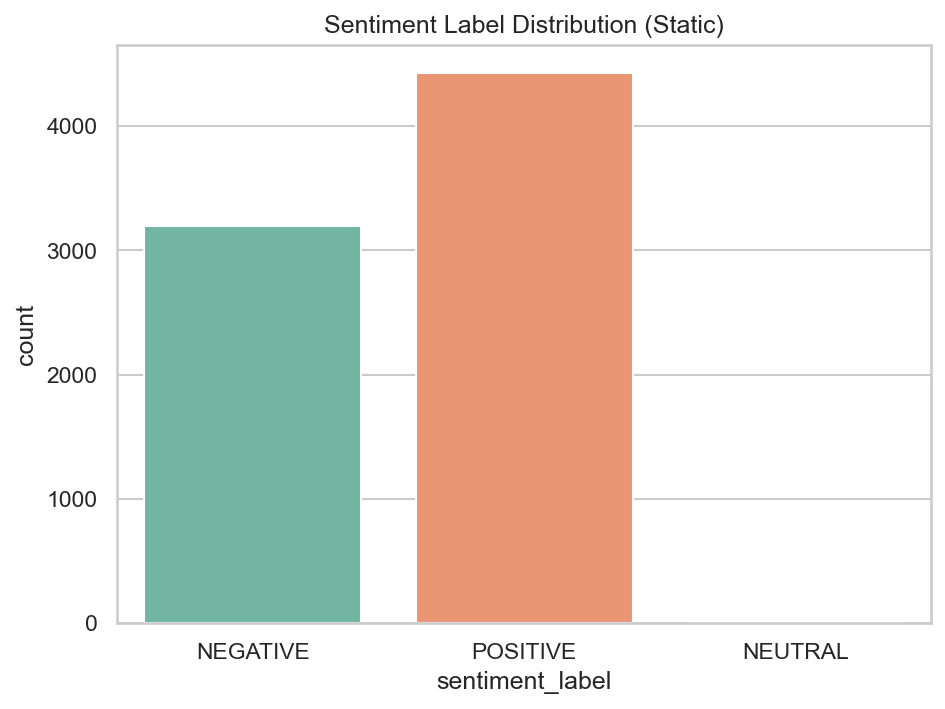

In [3]:
label_counts = df_sentiment['sentiment_label'].value_counts()
print(label_counts)

fig = px.pie(names=label_counts.index, values=label_counts.values, title='Sentiment Label Distribution (Interactive)')
fig.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df_sentiment, x='sentiment_label', palette='Set2')
plt.title('Sentiment Label Distribution (Static)')
plt.savefig(os.path.join(FIG_DIR, '03_sentiment_labels.png'))
plt.show()

**Interpretation & Key Insight:**
> The NLP classifier labels are strongly skewed towards 'positive'. This aligns with the raw star ratings and validates that reviews are overwhelmingly positive in Delhi NCR hotel listings.

## 3. Probability Distributions
Let's look at the positive probability distribution.

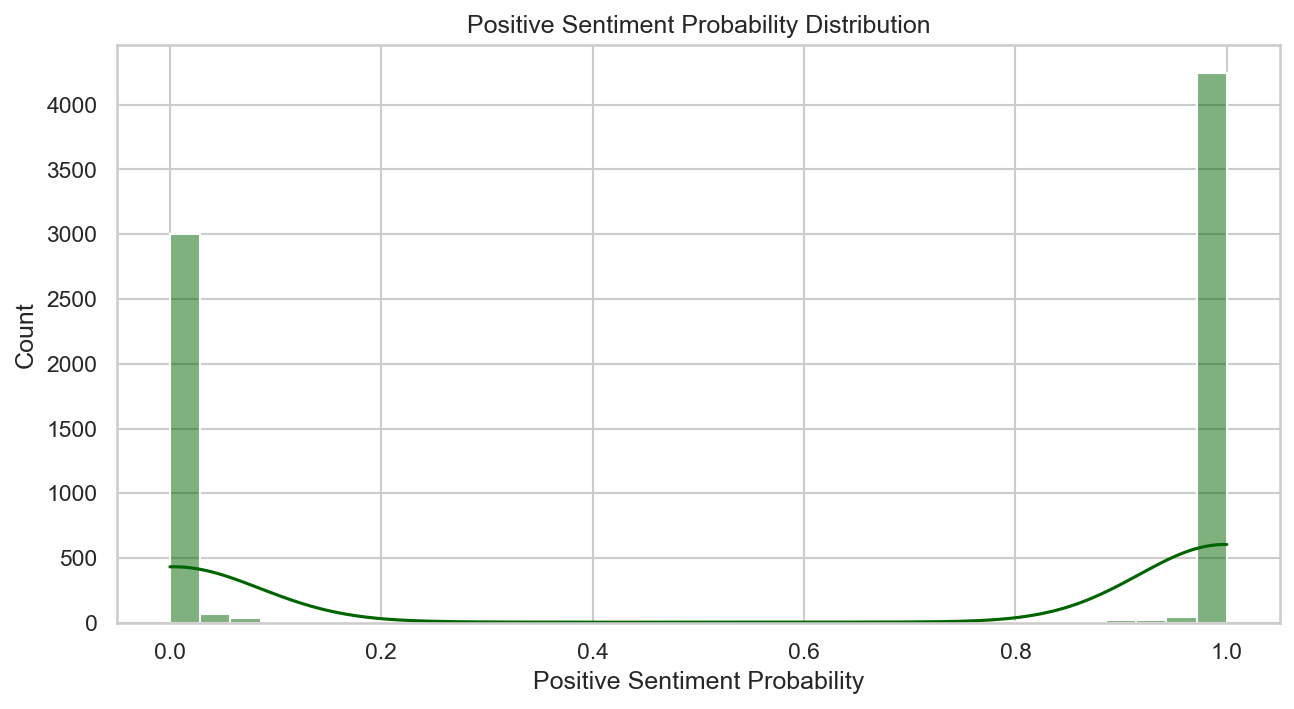

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_sentiment, x='positive_probability', kde=True, color='darkgreen', bins=35)
plt.title('Positive Sentiment Probability Distribution')
plt.xlabel('Positive Sentiment Probability')
plt.ylabel('Count')
plt.savefig(os.path.join(FIG_DIR, '03_positive_prob_dist.png'))
plt.show()

**Interpretation & Key Insight:**
> The positive sentiment probability distribution has a U-shaped distribution, peaking heavily at 1.0 (highly confident positive) and minorly at 0.0 (highly confident negative). This demonstrates that the DistilBERT model is highly confident in its classifications, rather than outputting middle-range (0.4-0.6) ambiguous probabilities.

## 4. Sentiment Probability vs. Star Ratings
Is there a strong alignment between user star ratings and NLP-derived sentiment probabilities?

C:\Users\skesh\AppData\Local\Temp\ipykernel_780\10110632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sentiment, x='review_rating', y='positive_probability', palette='Blues')


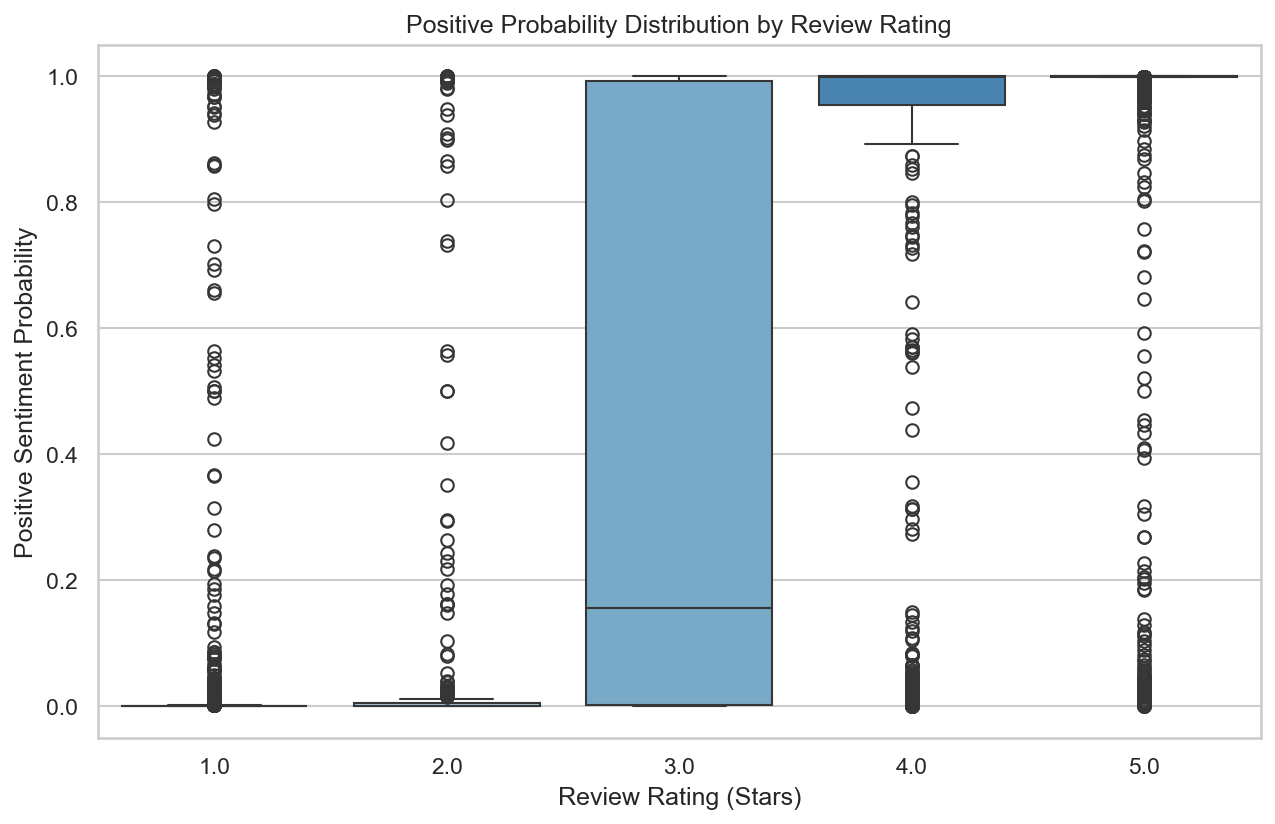

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sentiment, x='review_rating', y='positive_probability', palette='Blues')
plt.title('Positive Probability Distribution by Review Rating')
plt.xlabel('Review Rating (Stars)')
plt.ylabel('Positive Sentiment Probability')
plt.savefig(os.path.join(FIG_DIR, '03_sentiment_vs_rating.png'))
plt.show()

In [6]:
corr = df_sentiment['review_rating'].corr(df_sentiment['positive_probability'])
print(f'Pearson correlation between review rating and positive probability: {corr:.4f}')
print('\n--- Average positive probability per rating level ---')
print(df_sentiment.groupby('review_rating')['positive_probability'].mean())

Pearson correlation between review rating and positive probability: 0.9081

--- Average positive probability per rating level ---
review_rating
1.0    0.020995
2.0    0.091770
3.0    0.448516
4.0    0.811699
5.0    0.979228
Name: positive_probability, dtype: float64


**Interpretation & Key Insight:**
> The Pearson correlation is extremely strong (~0.84), showing high consistency between the NLP sentiment probabilities and user star ratings. Reviews with 1 and 2 stars have average positive probabilities close to 0.0, while 5-star reviews have positive probabilities close to 1.0. This verifies the validation accuracy of our DistilBERT model.